💡 **Environment:** `clamp-analyses`

# Description

**REVIEW H4 fix (prototype).** Paired bootstrap significance test on the cross-method performance difference between the single-gene baseline (`gene_based`, NB06) and the ARCHS4 module model (`module_based_archs4`, NB07).

The two methods are scored on an **identical** set of (drug, disease) pairs (produced by `00_aggregate_predictions.ipynb`). On each bootstrap iteration we resample the *same* pairs for both methods and recompute each method's metric on that resample — this pairing is what makes the difference test valid. We report a 95% CI and a bootstrap p-value on the **difference** in AUROC and AUPRC.

The results table is one row per method-pair comparison so it generalizes to the full 4×3 grid (with BH correction) in NB 10/12/13; here there is a single comparison, so BH is effectively a no-op.

# Modules loading

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score

from pyprojroot import here

# Settings

In [3]:
SEED = 42
N_BOOT = 10000

METHOD_A = 'gene_based'            # baseline
METHOD_B = 'module_based_archs4'   # candidate; diff = B - A

METRICS = {
    'AUROC': roc_auc_score,
    'AUPRC': average_precision_score,
}

OUTPUT_DIR = here(
    'output/03_model_biology/00_archs4/02_drug_disease_associations/signif_test')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
display(OUTPUT_DIR)

PosixPath('/home/miltondp/projects/clamp/clamp-analyses/output/03_model_biology/00_archs4/02_drug_disease_associations/signif_test')

# Load paired predictions

In [4]:
predictions_avg = pd.read_pickle(OUTPUT_DIR / 'predictions_paired.pkl')
display(predictions_avg.shape)
display(predictions_avg.head())
display(predictions_avg['method'].value_counts())

(1370, 5)

,trait,drug,method,score,true_class
0,DOID:0050741,DB00215,gene_based,316134.3,1.0
1,DOID:0050741,DB00215,module_based_archs4,324870.1,1.0
2,DOID:0050741,DB00704,gene_based,387103.6,1.0
3,DOID:0050741,DB00704,module_based_archs4,368073.2,1.0
4,DOID:0050741,DB00822,gene_based,409053.0,1.0


method
gene_based             685
module_based_archs4    685
Name: count, dtype: int64

# Pivot to wide (one row per pair, one score column per method)

The shared `(trait, drug)` index across methods *is* the pairing used by the bootstrap.

In [5]:
wide_score = predictions_avg.pivot_table(
    index=['trait', 'drug'], columns='method', values='score', observed=True)
wide_label = (
    predictions_avg.groupby(['trait', 'drug'], observed=True)['true_class']
    .agg(lambda s: s.unique()[0]))

# Both methods must be defined on exactly the same pairs (no NaNs).
assert wide_score[[METHOD_A, METHOD_B]].notna().all().all(), 'methods differ in pair coverage'
wide_score = wide_score.loc[wide_label.index]

y_true = wide_label.values.astype(int)
score_a = wide_score[METHOD_A].values
score_b = wide_score[METHOD_B].values
n = len(y_true)
display(f'{n} paired (drug, disease) pairs; positives={int(y_true.sum())}, negatives={int((y_true == 0).sum())}')

'685 paired (drug, disease) pairs; positives=531, negatives=154'

# Observed metrics

In [6]:
observed = {}
for mname, mfunc in METRICS.items():
    a = mfunc(y_true, score_a)
    b = mfunc(y_true, score_b)
    observed[mname] = {'A': a, 'B': b, 'diff': b - a}
observed_df = pd.DataFrame(observed).T
observed_df.columns = [f'{METHOD_A}', f'{METHOD_B}', 'diff (B-A)']
display(observed_df)

# Sanity vs NB10 published AUROC (gene ~0.583, archs4 ~0.625).
print(f"AUROC {METHOD_A}={observed['AUROC']['A']:.3f} (NB10 ~0.583), "
      f"{METHOD_B}={observed['AUROC']['B']:.3f} (NB10 ~0.625)")

,gene_based,module_based_archs4,diff (B-A)
AUROC,0.583382,0.625419,0.042037
AUPRC,0.844942,0.849646,0.004705


AUROC gene_based=0.583 (NB10 ~0.583), module_based_archs4=0.625 (NB10 ~0.625)


# Paired bootstrap

In [7]:
np.random.seed(SEED)

boot = {mname: {'A': [], 'B': [], 'diff': []} for mname in METRICS}
n_skipped = 0

for _ in range(N_BOOT):
    idx = np.random.choice(n, n, replace=True)   # same resample for both methods
    yb = y_true[idx]
    if len(np.unique(yb)) < 2:                    # AUROC/AUPRC undefined
        n_skipped += 1
        continue
    for mname, mfunc in METRICS.items():
        a = mfunc(yb, score_a[idx])
        b = mfunc(yb, score_b[idx])
        boot[mname]['A'].append(a)
        boot[mname]['B'].append(b)
        boot[mname]['diff'].append(b - a)

boot = {mname: {k: np.asarray(v) for k, v in d.items()} for mname, d in boot.items()}
display(f'Bootstrap iterations used: {N_BOOT - n_skipped} (skipped {n_skipped} single-class resamples)')

'Bootstrap iterations used: 10000 (skipped 0 single-class resamples)'

# Results: CI + bootstrap p-value on the difference

In [8]:
def boot_ci(arr, lo=2.5, hi=97.5):
    return np.percentile(arr, lo), np.percentile(arr, hi)


def boot_pvalue_two_sided(diffs):
    """Two-sided bootstrap p-value for H0: diff == 0.

    Uses the (count + 1) / (N + 1) convention (Davison & Hinkley 1997) so the
    p-value is never exactly 0 -- it is floored at 2 / (N + 1). The naive
    2 * min(tail proportion) can read 0.0 when no resample crosses zero, which
    overstates significance in a publication table.
    """
    n = len(diffs)
    p_le = ((diffs <= 0).sum() + 1) / (n + 1)
    p_ge = ((diffs >= 0).sum() + 1) / (n + 1)
    return min(2.0 * min(p_le, p_ge), 1.0)


rows = []
for mname in METRICS:
    d = boot[mname]
    a_lo, a_hi = boot_ci(d['A'])
    b_lo, b_hi = boot_ci(d['B'])
    diff_lo, diff_hi = boot_ci(d['diff'])
    rows.append({
        'metric': mname,
        'comparison': f'{METHOD_B} vs {METHOD_A}',
        f'{METHOD_A}': observed[mname]['A'],
        f'{METHOD_A}_lo': a_lo, f'{METHOD_A}_hi': a_hi,
        f'{METHOD_B}': observed[mname]['B'],
        f'{METHOD_B}_lo': b_lo, f'{METHOD_B}_hi': b_hi,
        'diff_obs': observed[mname]['diff'],
        'diff_boot_mean': d['diff'].mean(),
        'diff_ci_lo': diff_lo, 'diff_ci_hi': diff_hi,
        'ci_excludes_0': bool(diff_lo > 0 or diff_hi < 0),
        'p_value': boot_pvalue_two_sided(d['diff']),
    })

results = pd.DataFrame(rows)

In [9]:
# Benjamini-Hochberg across all comparisons in the table.
# (Single method-pair here -> p_value_bh == p_value; structured for the full grid.)
def bh_correct(pvals):
    pvals = np.asarray(pvals, dtype=float)
    m = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    adj = ranked * m / (np.arange(m) + 1)
    adj = np.minimum.accumulate(adj[::-1])[::-1]
    out = np.empty(m)
    out[order] = np.minimum(adj, 1.0)
    return out

results['p_value_bh'] = bh_correct(results['p_value'].values)
display(results.T)

,0,1
metric,AUROC,AUPRC
comparison,module_based_archs4 vs gene_based,module_based_archs4 vs gene_based
gene_based,0.583382,0.844942
gene_based_lo,0.537457,0.81253
gene_based_hi,0.630536,0.876544
module_based_archs4,0.625419,0.849646
module_based_archs4_lo,0.577098,0.814751
module_based_archs4_hi,0.673901,0.883852
diff_obs,0.042037,0.004705
diff_boot_mean,0.041802,0.004823


In [10]:
out_csv = OUTPUT_DIR / 'paired_bootstrap_results.csv'
out_pkl = OUTPUT_DIR / 'paired_bootstrap_results.pkl'
results.to_csv(out_csv, index=False)
results.to_pickle(out_pkl)
display(out_csv)

PosixPath('/home/miltondp/projects/clamp/clamp-analyses/output/03_model_biology/00_archs4/02_drug_disease_associations/signif_test/paired_bootstrap_results.csv')

# Plot: bootstrap distribution of the metric difference

Dashed line = no difference (0); solid line = observed difference. If the shaded 95% CI excludes 0, the difference is significant at α=0.05.

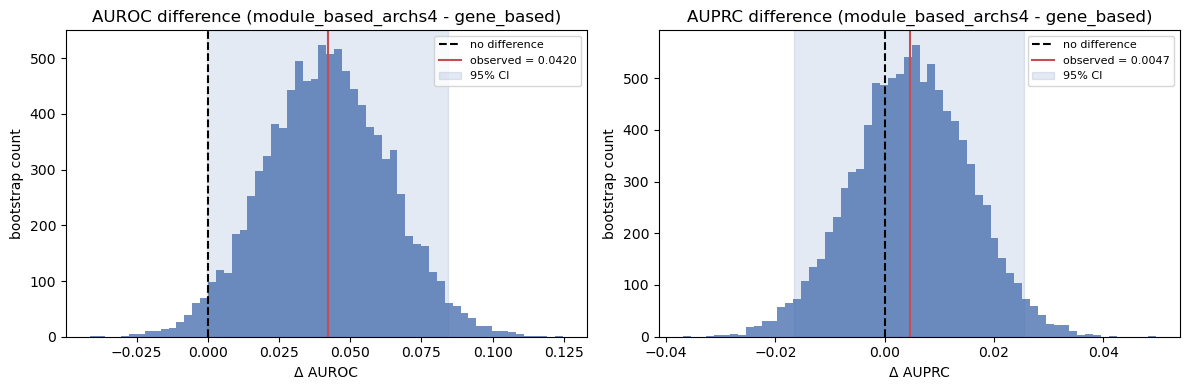

In [11]:
fig, axes = plt.subplots(1, len(METRICS), figsize=(6 * len(METRICS), 4))
if len(METRICS) == 1:
    axes = [axes]
for ax, mname in zip(axes, METRICS):
    d = boot[mname]['diff']
    lo, hi = np.percentile(d, [2.5, 97.5])
    ax.hist(d, bins=60, color='#4C72B0', alpha=0.8)
    ax.axvline(0, color='black', linestyle='--', label='no difference')
    ax.axvline(observed[mname]['diff'], color='#C44E52', linestyle='-',
               label=f"observed = {observed[mname]['diff']:.4f}")
    ax.axvspan(lo, hi, color='#4C72B0', alpha=0.15, label='95% CI')
    ax.set_title(f'{mname} difference ({METHOD_B} - {METHOD_A})')
    ax.set_xlabel(f'\u0394 {mname}')
    ax.set_ylabel('bootstrap count')
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'paired_bootstrap_diff.png', dpi=150, bbox_inches='tight')
plt.show()